# Componente práctico del curso Minería para Big Data

El presente Notebook contiene la información relacionada con el desarrollo de las actividades 1 y 2 del curso de Minería para Big Data relacionados con el proceso de carga y limpieza del documento compartido, denominado 'Anexo 1 - Dataset3.csv'; así como el proceso de modelado y validación de dos modelos de Machine Learning, uno de árboles de decisión (Decision trees) y otro de bosque aleatorio (Random Forest). 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exploración y preparación de datos

Antes de iniciar el entrenamiento de los modelos que se van a explorar en el presente Notebook, se debe de limpiar la información suministrada y entender un poco más el contenido de los datos con el fin de mejorar la interpretación de los resultados y ajustar adecuadamente los modelos.

In [2]:
# Importamos el dataset desde el repositorio de GitHub dispuesto para el desarrollo del presente ejercicio.
#  Es de anotar que, una vez revisado el documento anexo, se encontró que el separador de los datos no es coma (,), sino el 
#  punto y coma (;) por lo que se debe de indicar esto en el momento de la importación.
df = pd.read_csv('https://raw.githubusercontent.com/Jero2110/Big_Data_Phase04/refs/heads/main/analysis/data/Anexo%201%20-%20Dataset3.csv', sep=";")


# Presentamos las primeras filas con el fin de verificar que la información se haya cargado correctamente
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


Como se puede observar anteriormente, el dataset se encuentra compuesto de 7 columnas, de las cuales podemos tomar cinco (5) de ellas para realizar un análisis con los modelos de Machine Learning propuestos para la presente tarea. Las columnas `user_id` y `loyalty_score` no hacen parte de las columnas que aportan información al modelo debido a que su contenido hace referencia a un indicador único, posiblemente autoincremental (`user_id`), o a las clases con las cuales se espera entrenar el modelo (`loyalty_score`).

En este orden de ideas, se tomará el campo `loyalty_score` para generar las clases mediante las cuales los modelos seleccionados deben de entrenarse para predecir a cuál de estos pertenecerá según las demás variables de estudio.

Sin embargo, antes de iniciar con el proceso de entrenamiento, se debe de verificar la calidad de los registros para evitar inconvenientes al momento del modelado o errores de interpretación de los resultados.

In [3]:
round(df.describe(),2)

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.00,238.00,238.00,238.00,238.00,238.00
mean,119.50,38.68,57407.56,425.63,6.79,19.80
std,68.85,9.35,11403.88,140.05,1.90,4.56
min,1.00,22.00,30000.00,150.00,3.00,10.00
25%,60.25,31.00,50000.00,320.00,5.50,17.00
50%,119.50,39.00,59000.00,440.00,7.00,20.00
75%,178.75,46.75,66750.00,527.50,8.28,23.00
max,238.00,55.00,75000.00,640.00,9.50,28.00


In [4]:
# Creamos una función para los boxplot de las columnas de interés
def grafico_boxplot(data, col_name, title, ax=None):

    # Si no se proporciona un eje, usamos el eje actual o creamos uno
    if ax is None:
        ax = plt.gca()
    
    sns.boxplot(data=data[[col_name]], ax=ax)
    ax.set_title(title)

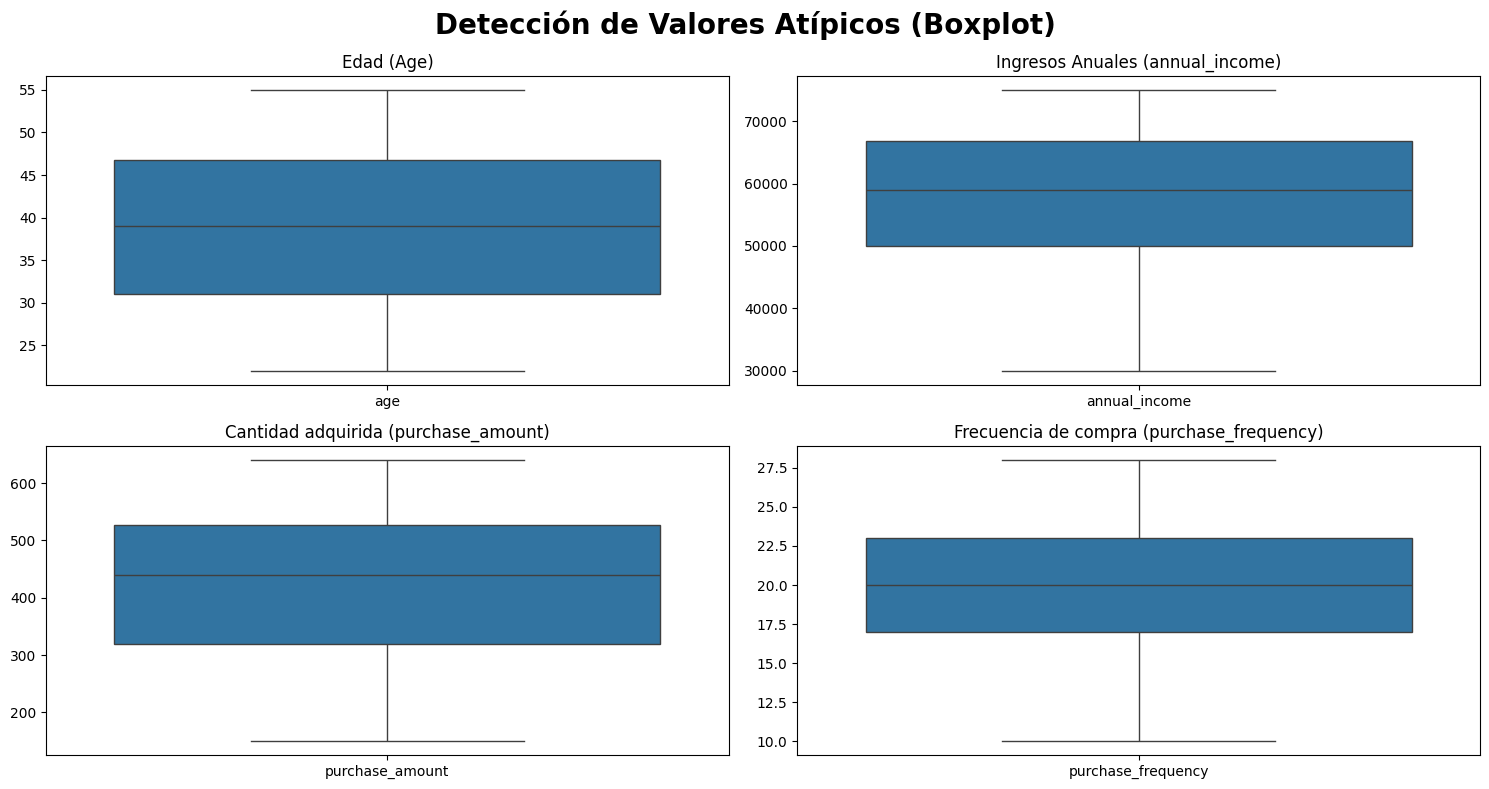

In [5]:
# 1. Boxplot para las columnas que se utilizarán en el entrenamiento del modelo
cols_boxplot = {
    'Edad (Age)': 'age',
    'Ingresos Anuales (annual_income)': 'annual_income',
    'Cantidad adquirida (purchase_amount)': 'purchase_amount',
    'Frecuencia de compra (purchase_frequency)': 'purchase_frequency'
}

# Configuramos la figura para los Boxplots
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

fig.suptitle('Detección de Valores Atípicos (Boxplot)',
             fontsize=20, 
             fontweight='bold')

axes_flat = axes.flatten()

for i, (subtitulo, df_col) in enumerate(cols_boxplot.items()):
    grafico_boxplot(df, df_col, subtitulo, axes_flat[i])

plt.tight_layout()
plt.show()

In [8]:
# Creamos una función para los histogramas de las columnas de interés
def grafico_histograma(data, col_name, title, ax=None):

    # Si no se proporciona un eje, usamos el eje actual o creamos uno
    if ax is None:
        ax = plt.gca()
    
    sns.histplot(data, x=data[col_name], kde=True, color='teal', ax=ax)
    
    ax.set_title(title)
    ax.set_ylabel('Frecuencia')

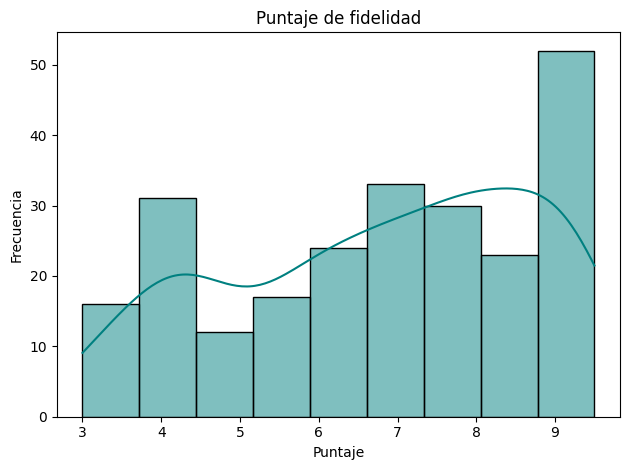

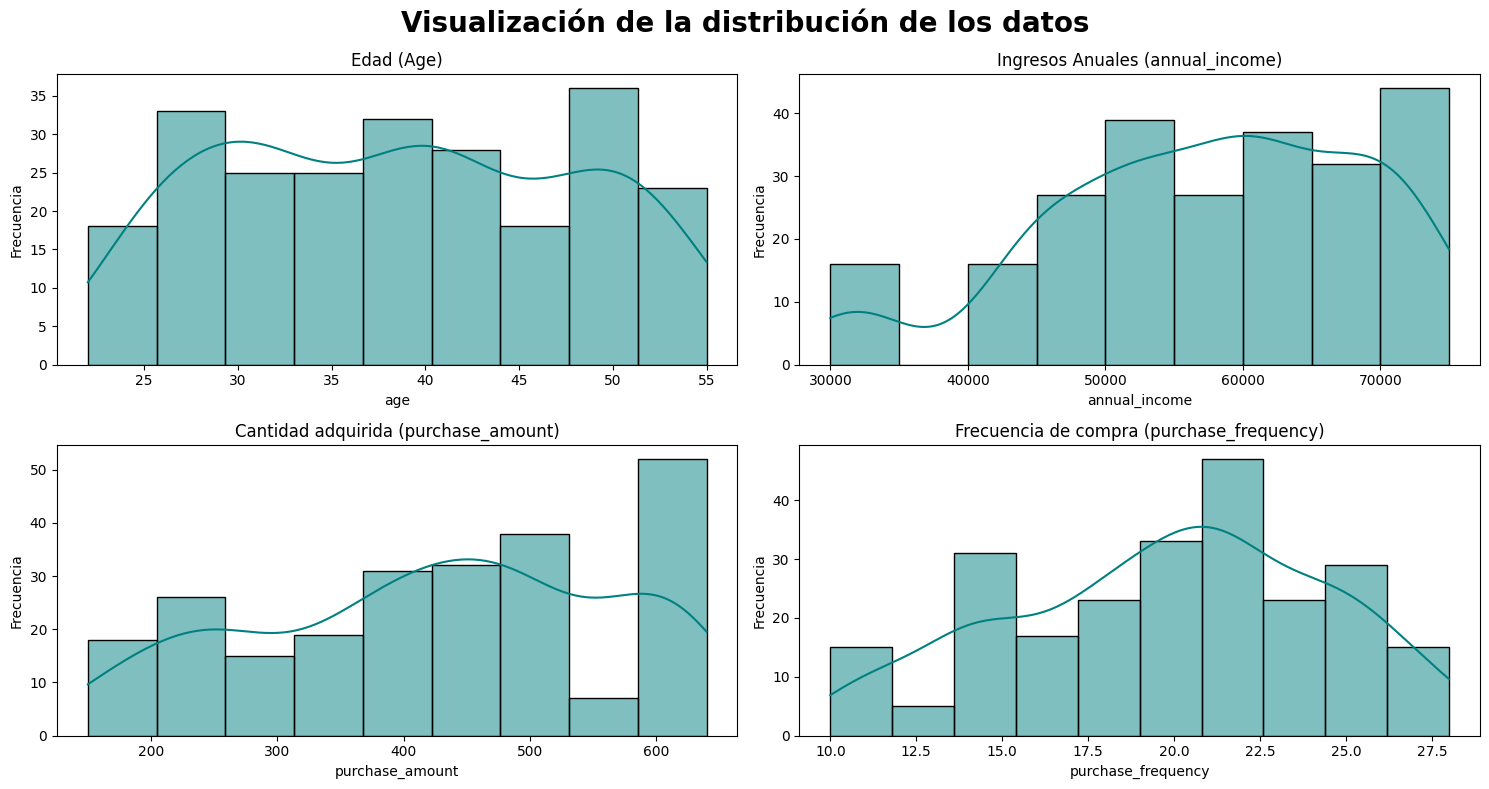

In [10]:

# 2. Histogramas
#  Para la clase
plt.plot(figsize=(16, 6))

grafico_histograma(df, 'loyalty_score', 'Puntaje de fidelidad')

plt.xlabel('Puntaje')
plt.tight_layout()
plt.show()

#  Para las demás columnas de interés
cols_histograma = {
    'Edad (Age)': 'age',
    'Ingresos Anuales (annual_income)': 'annual_income',
    'Cantidad adquirida (purchase_amount)': 'purchase_amount',
    'Frecuencia de compra (purchase_frequency)': 'purchase_frequency'
}

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

fig.suptitle('Visualización de la distribución de los datos',
             fontsize=20, 
             fontweight='bold')

axes_flat = axes.flatten()

for i, (subtitulo, df_col) in enumerate(cols_boxplot.items()):
    grafico_histograma(df, df_col, subtitulo, axes_flat[i])


plt.tight_layout()
plt.show()

In [11]:
limites = [
    (df['loyalty_score'] >= 8.5),
    (df['loyalty_score'] >= 7.3) & (df['loyalty_score'] < 8.5),
    (df['loyalty_score'] >= 6.1) & (df['loyalty_score'] < 7.3),
    (df['loyalty_score'] >= 4.9) & (df['loyalty_score'] < 6.1),
    (df['loyalty_score'] < 4.9)
]

categorias = ['Platino', 'Oro', 'Plata', 'Bronce', 'Casual']

df['nivel'] = np.select(limites, categorias, default='Sin Puntaje')

df['nivel']

,nivel
0,Casual
1,Plata
2,Oro
3,Casual
4,Casual
...,...
233,Plata
234,Plata
235,Platino
236,Bronce


## Árboles de decisión (Decision Trees)

Para entender mejor los árboles de decisión (o Decision Trees, en inglés) debemos de consultar la teoría, la cual dice que:

>"Un árbol de decisión es un algoritmo de aprendizaje supervisado no paramétrico que se utiliza tanto para tareas de clasificación como de regresión. Posee una estructura jerárquica en forma de árbol, compuesta por un nodo raíz, ramas, nodos internos y nodos hoja.
><p>(...) un árbol de decisión comienza con un nodo raíz, que no tiene ramas entrantes. Las ramas que parten del nodo raíz alimentan los nodos internos, también conocidos como nodos de decisión. Con base en las características disponibles, ambos tipos de nodos realizan evaluaciones para formar subconjuntos homogéneos, representados por los nodos hoja o nodos terminales. Los nodos hoja representan todos los resultados posibles dentro del conjunto de datos."

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [13]:
# 1. Preparamos los datos (X = Características, y = Categoría)
X = df[['age', 'annual_income', 'purchase_amount', 'purchase_frequency']]
y = df['nivel'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Configuramos el Árbol y la búsqueda de hiperparámetros
param_grid = {'max_depth': [3, 5, 7, 10], 'criterion': ['gini', 'entropy']}
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print(f"Mejor profundidad encontrada: {grid.best_params_['max_depth']}")

Mejor profundidad encontrada: 5


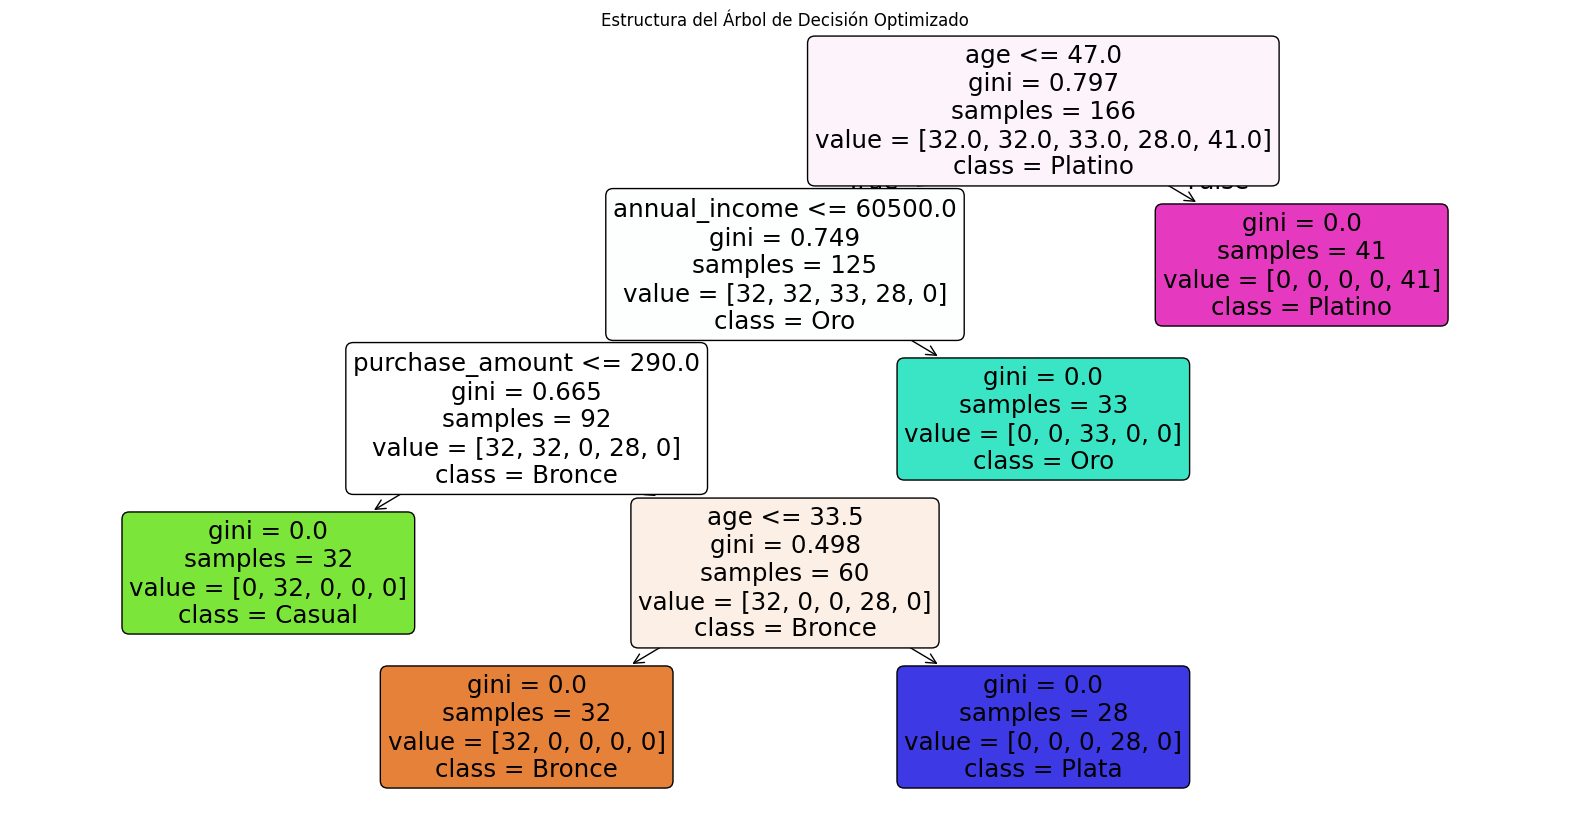

In [14]:
plt.figure(figsize=(20,10))
plot_tree(best_tree, feature_names=X.columns, class_names=best_tree.classes_, filled=True, rounded=True)
plt.title("Estructura del Árbol de Decisión Optimizado")
plt.show()

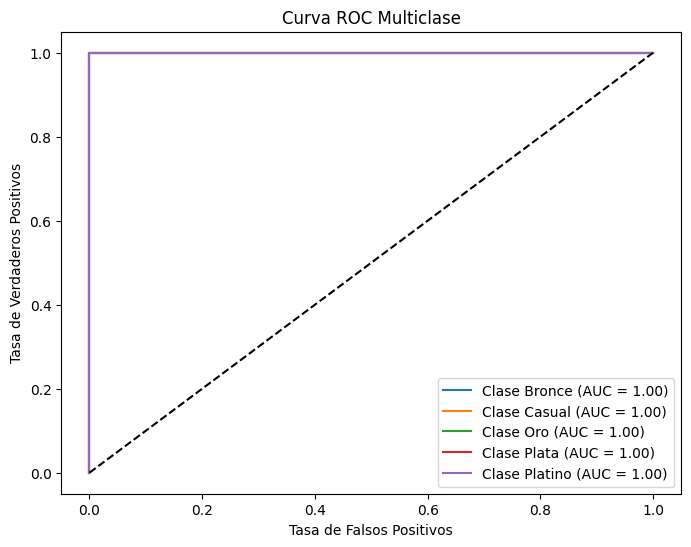

In [16]:
# Binarizar la salida para multiclase (si aplica)
y_test_bin = label_binarize(y_test, classes=best_tree.classes_)
y_score = best_tree.predict_proba(X_test)

plt.figure(figsize=(8, 6))

# Graficar curva para cada clase
for i in range(len(best_tree.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {best_tree.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Línea aleatoria
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Multiclase')
plt.legend(loc="lower right")
plt.show()


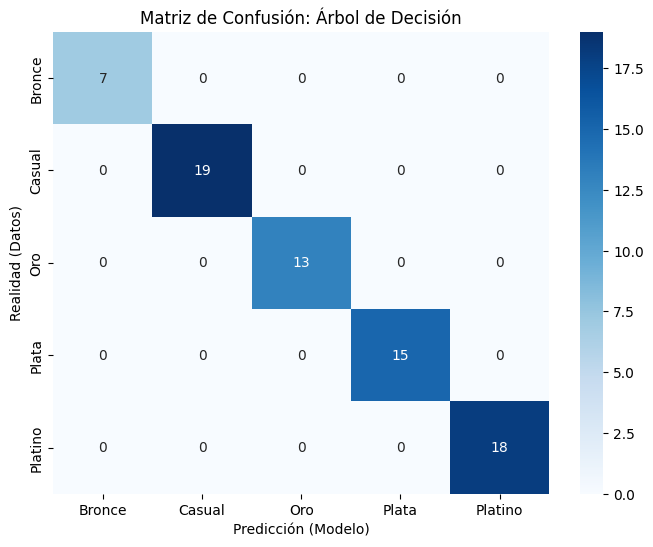

In [33]:
# 1. Obtener las predicciones del modelo
y_pred_tree = best_tree.predict(X_test)

# 2. Calcular la matriz
cm = confusion_matrix(y_test, y_pred_tree, labels=best_tree.classes_)

# 3. Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_tree.classes_, 
            yticklabels=best_tree.classes_)

plt.title('Matriz de Confusión: Árbol de Decisión')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Datos)')
plt.show()

In [34]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

      Bronce       1.00      1.00      1.00         7
      Casual       1.00      1.00      1.00        19
         Oro       1.00      1.00      1.00        13
       Plata       1.00      1.00      1.00        15
     Platino       1.00      1.00      1.00        18

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



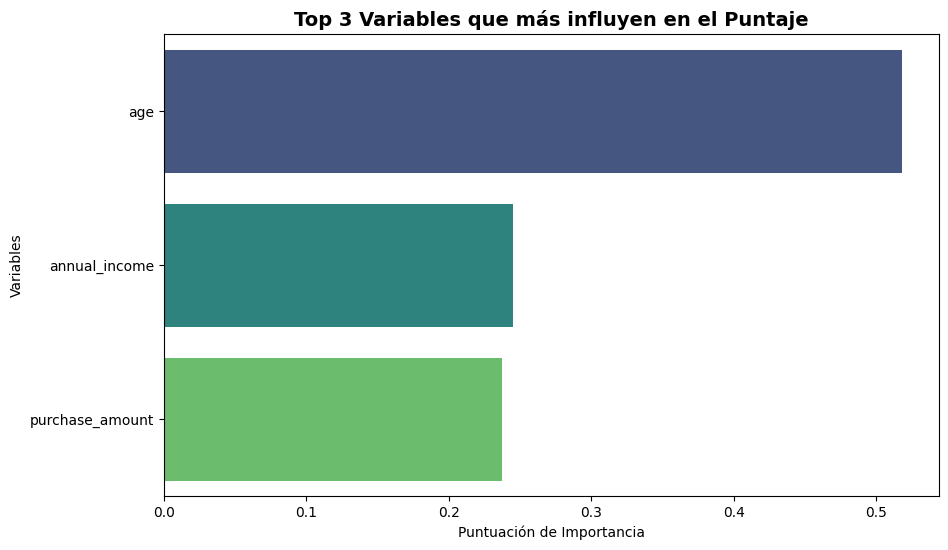

Las 3 variables determinantes son:
          Variable  Importancia
0              age     0.517853
1    annual_income     0.245095
2  purchase_amount     0.237051


In [21]:
# 1. Extraer la importancia de las variables
importancias = best_tree.feature_importances_
nombres_vars = X.columns

# 2. Crear un DataFrame y ordenar para obtener las 3 mejores
df_importancia = pd.DataFrame({'Variable': nombres_vars, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(3)

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis', hue='Variable', legend=False)

plt.title('Top 3 Variables que más influyen en el Puntaje', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variables')
plt.show()

# Imprimir las variables exactas
print("Las 3 variables determinantes son:")
print(df_importancia)


## Bosque Aleatorio (Random Forest)

> El algoritmo de bosque aleatorio es una extensión del método de bagging, ya que utiliza tanto bagging como aleatorización de características para crear un bosque de árboles de decisión no correlacionados. La aleatorización de características, también conocida como bagging de características o método de subespacio aleatorio, genera un subconjunto aleatorio de características, lo que garantiza una baja correlación entre los árboles de decisión. Esta es una diferencia clave entre los árboles de decisión y los bosques aleatorios. Mientras que los árboles de decisión consideran todas las posibles divisiones de características, los bosques aleatorios seleccionan solo un subconjunto de ellas.

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
# 1. Configurar el modelo y los parámetros a probar
param_grid_rf = {
    'n_estimators': [100, 200], # Número de árboles en el bosque
    'max_depth': [5, 10, None],
    'criterion': ['gini', 'entropy']
}

# 2. Búsqueda con Validación Cruzada (cv=5)
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(f"Mejor configuración: {grid_rf.best_params_}")


Mejor configuración: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}


In [25]:
importancias_rf = best_rf.feature_importances_
df_imp_rf = pd.DataFrame({'Variable': X.columns, 'Importancia': importancias_rf})
df_imp_rf = df_imp_rf.sort_values(by='Importancia', ascending=False).head(3)

# Visualización (Usa el mismo código de barplot que usamos antes)
print("Top 3 variables según Random Forest:")
print(df_imp_rf)


Top 3 variables según Random Forest:
          Variable  Importancia
1    annual_income     0.307402
0              age     0.294113
2  purchase_amount     0.249427


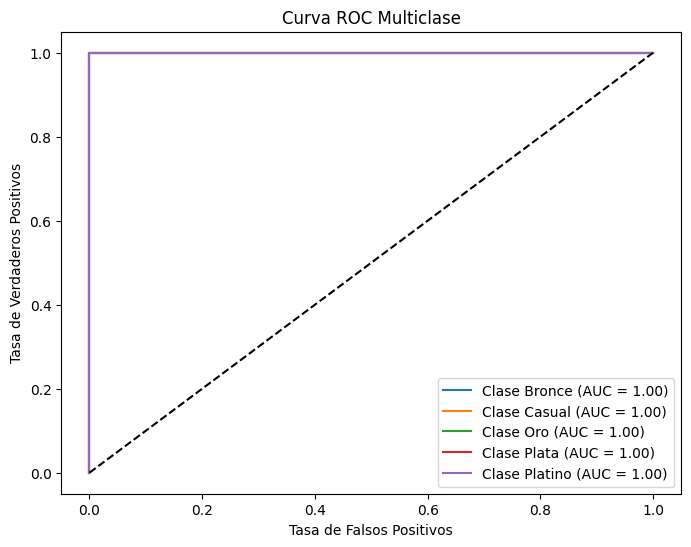

In [26]:
# Binarizar la salida para multiclase (si aplica)
y_test_bin = label_binarize(y_test, classes=best_rf.classes_)
y_score = best_rf.predict_proba(X_test)

plt.figure(figsize=(8, 6))

# Graficar curva para cada clase
for i in range(len(best_rf.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {best_rf.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Línea aleatoria
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Multiclase')
plt.legend(loc="lower right")
plt.show()

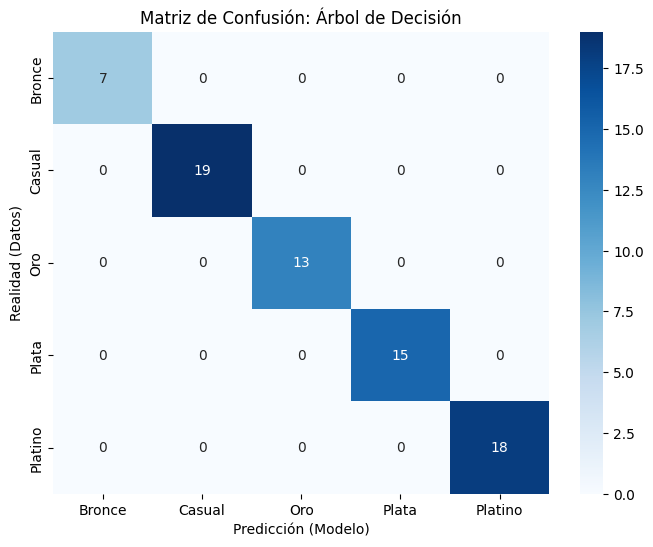

In [35]:
# 1. Obtener las predicciones del modelo
y_pred_rf = best_rf.predict(X_test)

# 2. Calcular la matriz
cm = confusion_matrix(y_test, y_pred_rf, labels=best_rf.classes_)

# 3. Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_rf.classes_, 
            yticklabels=best_rf.classes_)

plt.title('Matriz de Confusión: Árbol de Decisión')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Datos)')
plt.show()

In [36]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

      Bronce       1.00      1.00      1.00         7
      Casual       1.00      1.00      1.00        19
         Oro       1.00      1.00      1.00        13
       Plata       1.00      1.00      1.00        15
     Platino       1.00      1.00      1.00        18

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72

